Tutorials and Sources:
https://courses.spatialthoughts.com/python-dataviz.html

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

Book: Introduction to GIS Programming by Dr. Qiusheng Wu.

In [1]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/all_counties_zip.csv')
df

,zipCode,pov_rate,MoE
0,ZCTA5 28701,4.80%,± 3.8%
1,ZCTA5 28704,6.40%,± 2.0%
2,ZCTA5 28709,3.10%,± 3.3%
3,ZCTA5 28711,8.10%,± 1.9%
4,ZCTA5 28714,14.60%,± 2.3%
5,ZCTA5 28715,11.40%,± 2.9%
6,ZCTA5 28730,12.70%,± 7.1%
7,ZCTA5 28732,7.00%,± 2.4%
8,ZCTA5 28740,16.70%,± 9.6%
9,ZCTA5 28743,12.70%,± 7.0%


In [4]:
df['zipcode'] = df['zipCode'].str.replace('ZCTA5 ', '').str.strip()
df['pov_rate'] = df['pov_rate'].str.replace('%', '').astype(float)
df = df.drop(columns=['zipCode', 'MoE'])
df

,pov_rate,zipcode
0,4.8,28701
1,6.4,28704
2,3.1,28709
3,8.1,28711
4,14.6,28714
5,11.4,28715
6,12.7,28730
7,7.0,28732
8,16.7,28740
9,12.7,28743


In [7]:
import requests

url = (
    "https://www.fema.gov/api/open/v2/"
    "IndividualsAndHouseholdsProgramValidRegistrations"
    "?$filter=disasterNumber%20eq%204827"
    "&$select=disasterNumber,county,damagedZipCode,"
    "grossIncome,homeOwnersInsurance,ihpEligible,ihpAmount,haEligible,haAmount,"
    "destroyed,foundationDamageAmount,onaEligible,onaAmount,id"
    "&$top=10000"
    "&$format=jsona"
)

r = requests.get(url)
print(r.status_code)

200


In [8]:
data = r.json()
df_fema = pd.DataFrame(data)
df_fema

,disasterNumber,county,damagedZipCode,grossIncome,homeOwnersInsurance,ihpEligible,ihpAmount,haEligible,haAmount,destroyed,foundationDamageAmount,onaEligible,onaAmount,id
0,4827,McDowell (County),28752,"$15,000-$30,000",False,False,0.00,False,0.00,False,0,False,0.0,1252953021
1,4827,Buncombe (County),28778,"$15,000-$30,000",False,False,0.00,False,0.00,False,0,False,0.0,1252953022
2,4827,Buncombe (County),28730,"$30,001-$60,000",True,True,1023.90,False,0.00,False,0,True,1023.9,1252953023
3,4827,Polk (County),28722,"$30,001-$60,000",True,True,5043.31,True,779.31,False,0,True,4264.0,1252953024
4,4827,Henderson (County),28732,"$60,001-$120,000",True,True,1898.00,False,0.00,False,0,True,1898.0,1252953025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4827,Mitchell (County),28777,"$30,001-$60,000",False,False,0.00,False,0.00,False,0,False,0.0,1252963016
9996,4827,Burke (County),28655,"$15,000-$30,000",True,True,5702.19,True,1438.19,False,0,True,4264.0,1252963017
9997,4827,Buncombe (County),28801,"<$15,000",False,True,750.00,False,0.00,False,0,True,750.0,1252963018
9998,4827,Rutherford (County),28018,"$30,001-$60,000",True,True,25788.00,True,21524.00,False,0,True,4264.0,1252963019


In [9]:
wnc_zips = df['zipcode'].tolist()

In [10]:
wnc_fema = df_fema[df_fema['damagedZipCode'].isin(wnc_zips)]
wnc_fema

,disasterNumber,county,damagedZipCode,grossIncome,homeOwnersInsurance,ihpEligible,ihpAmount,haEligible,haAmount,destroyed,foundationDamageAmount,onaEligible,onaAmount,id
0,4827,McDowell (County),28752,"$15,000-$30,000",False,False,0.0,False,0.0,False,0,False,0.0,1252953021
1,4827,Buncombe (County),28778,"$15,000-$30,000",False,False,0.0,False,0.0,False,0,False,0.0,1252953022
2,4827,Buncombe (County),28730,"$30,001-$60,000",True,True,1023.9,False,0.0,False,0,True,1023.9,1252953023
4,4827,Henderson (County),28732,"$60,001-$120,000",True,True,1898.0,False,0.0,False,0,True,1898.0,1252953025
5,4827,Buncombe (County),28806,0,False,False,0.0,False,0.0,False,0,False,0.0,1252953026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,4827,Buncombe (County),28701,"$15,000-$30,000",False,True,750.0,False,0.0,False,0,True,750.0,1252963010
9990,4827,Buncombe (County),28805,"$30,001-$60,000",True,True,750.0,False,0.0,False,0,True,750.0,1252963011
9991,4827,Buncombe (County),28715,"$30,001-$60,000",True,False,0.0,False,0.0,False,0,False,0.0,1252963012
9997,4827,Buncombe (County),28801,"<$15,000",False,True,750.0,False,0.0,False,0,True,750.0,1252963018


In [13]:
gdf = gpd.read_file('/content/tl_2020_us_zcta520.shp')
gdf

,ZCTA5CE20,GEOID20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
0,35592,35592,B5,G6350,S,298552385,235989,+33.7427261,-088.0973903,"POLYGON ((-88.24735 33.6539, -88.24713 33.6541..."
1,35616,35616,B5,G6350,S,559506992,41870756,+34.7395036,-088.0193814,"POLYGON ((-88.13997 34.58184, -88.13995 34.582..."
2,35621,35621,B5,G6350,S,117838488,409438,+34.3350314,-086.7270557,"POLYGON ((-86.81659 34.3496, -86.81648 34.3496..."
3,35651,35651,B5,G6350,S,104521045,574316,+34.4609087,-087.4801507,"POLYGON ((-87.53087 34.42492, -87.53082 34.429..."
4,36010,36010,B5,G6350,S,335675180,236811,+31.6598950,-085.8128958,"POLYGON ((-85.95712 31.67744, -85.95676 31.677..."
...,...,...,...,...,...,...,...,...,...,...
33786,10540,10540,B5,G6350,S,1394970,27777,+41.3259819,-073.7277119,"POLYGON ((-73.7358 41.33577, -73.73501 41.3358..."
33787,23081,23081,B5,G6350,S,7753698,14654483,+37.1935699,-076.7525080,"POLYGON ((-76.79774 37.21409, -76.79134 37.220..."
33788,23147,23147,B5,G6350,S,143646,0,+37.3696361,-077.0391136,"POLYGON ((-77.04292 37.36996, -77.04143 37.370..."
33789,23298,23298,B5,G6350,S,288664,0,+37.5417074,-077.4295300,"POLYGON ((-77.43284 37.54038, -77.43262 37.540..."


In [14]:
wnc_gdf = gdf[gdf['ZCTA5CE20'].isin(wnc_zips)]
print(wnc_gdf.head(10))

      ZCTA5CE20 GEOID20 CLASSFP20 MTFCC20 FUNCSTAT20    ALAND20  AWATER20  \
5200      28762   28762        B5   G6350          S  247382539    435063   
5589      28805   28805        B5   G6350          S   68610275     40781   
6401      28704   28704        B5   G6350          S   78035849   1837917   
6404      28803   28803        B5   G6350          S   99367866    921631   
6514      28709   28709        B5   G6350          S  133486780      3489   
25553     28757   28757        B5   G6350          S    7053724      7754   
25728     28714   28714        B5   G6350          S  667644953      5879   
25738     28715   28715        B5   G6350          S  202148638    352649   
25833     28787   28787        B5   G6350          S  205971198     39241   
25907     28801   28801        B5   G6350          S   13230942    236287   

        INTPTLAT20    INTPTLON20  \
5200   +35.6353341  -082.1897724   
5589   +35.6138542  -082.4797046   
6401   +35.4614292  -082.5708149   
6404   +

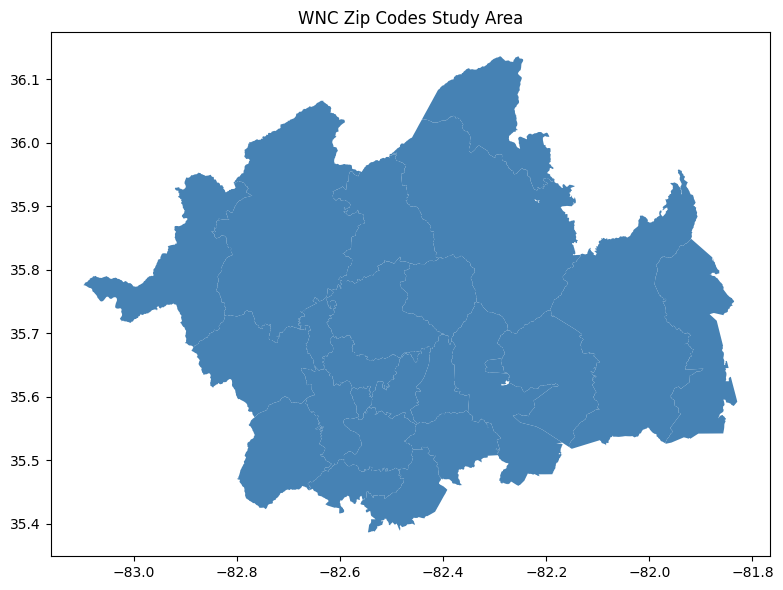

In [18]:
wnc_merged = wnc_gdf.merge(
    df,
    left_on='ZCTA5CE20',
    right_on='zipcode',
    how='left',
)

fig, ax = plt.subplots(figsize=(10,6))
wnc_merged.plot(
    ax=ax,
    color='steelblue',
)
ax.set_title('WNC Zip Codes Study Area')
plt.tight_layout()
plt.show()

In [20]:
fema_merged = wnc_merged.merge(
    wnc_fema,
    left_on='ZCTA5CE20',
    right_on='damagedZipCode',
    how='left',
)
print(fema_merged.columns.tolist())

['ZCTA5CE20', 'GEOID20', 'CLASSFP20', 'MTFCC20', 'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20', 'geometry', 'pov_rate', 'zipcode', 'disasterNumber', 'county', 'damagedZipCode', 'grossIncome', 'homeOwnersInsurance', 'ihpEligible', 'ihpAmount', 'haEligible', 'haAmount', 'destroyed', 'foundationDamageAmount', 'onaEligible', 'onaAmount', 'id']


In [23]:
zip_summ = fema_merged.groupby('damagedZipCode').agg(
    total_apps=('id', 'count'),
    total_ha=('haAmount', 'sum'),
    avg_ha=('haAmount', 'mean'),
    pov_rate=('pov_rate', 'first'),
    pct_HO_insur=('homeOwnersInsurance', 'mean'),
    total_destroyed=('destroyed', 'sum'),
    geom=('geometry', 'first')
).reset_index()

print(zip_summ[['damagedZipCode', 'total_apps', 'total_destroyed', 'pct_HO_insur']].head(10))

  damagedZipCode  total_apps  total_destroyed  pct_HO_insur
0          28701          34                0      0.500000
1          28704         217                1      0.419355
2          28709          71                2      0.422535
3          28711         335                4      0.534328
4          28714         458                9      0.617904
5          28715         188                1      0.377660
6          28730         195                3      0.666667
7          28732         196                0      0.561224
8          28740          61                2      0.573770
9          28743          38                0      0.500000


In [24]:
zips_gdf = gpd.GeoDataFrame(zip_summ, geometry='geom', crs='4326')

In [34]:
income_ha = fema_merged.groupby('grossIncome').agg(
    avg_ha_amount=('haAmount', 'mean'),
    total_apps=('haAmount', 'count'),
    total_ha=('haAmount', 'sum')
).reset_index()

incomeOrder = [
    '<$15,000',
    '$15,000-$30,000',
    '$30,001-$60,000',
    '$60,001-$120,000',
    '$120,001-$175,000',
    '>$175,000'
]

income_ha['grossIncome'] = pd.Categorical(
    income_ha['grossIncome'],
    categories=incomeOrder,
    ordered=True
)

income_ha = income_ha.sort_values('grossIncome')
print(income_ha)

         grossIncome  avg_ha_amount  total_apps    total_ha
5           <$15,000    2150.899155         592  1273332.30
1    $15,000-$30,000    2718.576043        1016  2762073.26
2    $30,001-$60,000    3015.907084        1303  3929726.93
3   $60,001-$120,000    5236.950888         845  4425223.50
0  $120,001-$175,000    4906.482427         206  1010735.38
6          >$175,000    4399.853580         162   712776.28
4                NaN    3019.594384         942  2844457.91


In [36]:
income_clean = income_ha[income_ha['grossIncome'] != '0'].copy()

income_clean['grossIncome'] = pd.Categorical(
    income_clean['grossIncome'],
    categories=incomeOrder,
    ordered=True
)

income_clean['grossIncome'] = income_clean['grossIncome'].astype(str)
income_clean['grossIncome'] = income_clean['grossIncome'].replace('nan', 'Not Reported')

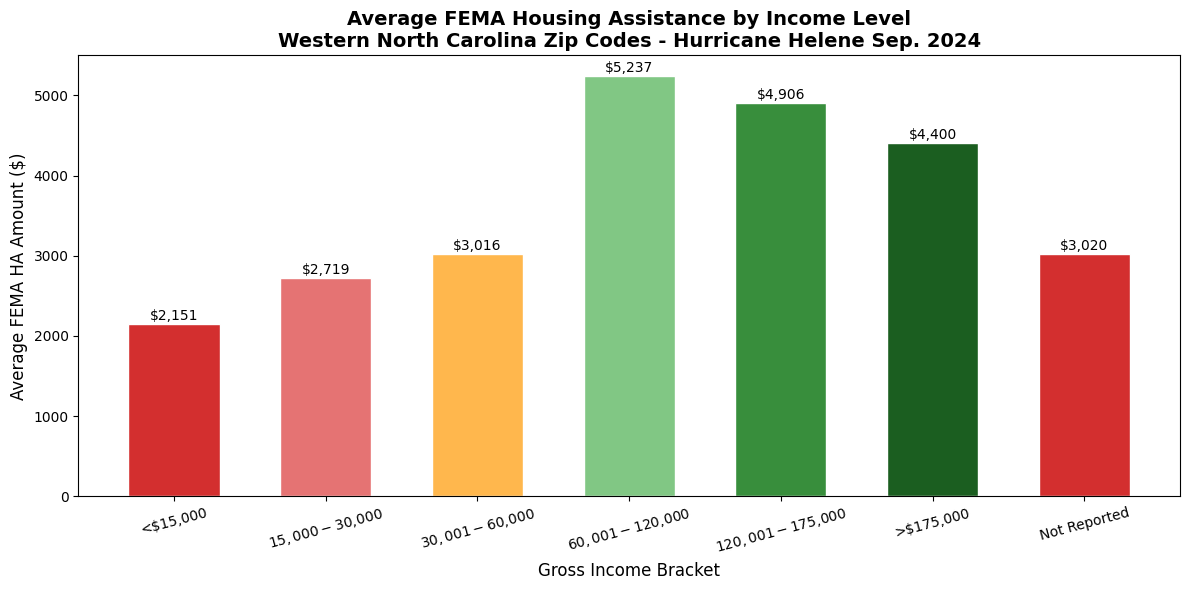

In [49]:
fig, ax = plt.subplots(figsize=(12,6))

colors = ['#d32f2f', '#e57373', '#ffb74d',
          '#81c784', '#388e3c', '#1b5e20']

bars = ax.bar(
    income_clean['grossIncome'],
    income_clean['avg_ha_amount'],
    color=colors,
    edgecolor='white',
    width=0.6
)

for bar in bars:
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 50,
      f'${bar.get_height():,.0f}',
      ha='center', fontsize=10,
  )

ax.set_ylabel('Average FEMA HA Amount ($)', fontsize=12)
ax.set_xlabel('Gross Income Bracket', fontsize=12)
ax.set_title(
    'Average FEMA Housing Assistance by Income Level\n'
    'Western North Carolina Zip Codes - Hurricane Helene Sep. 2024',
    fontsize=14, fontweight='bold'
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('Avg_Inc_BarChart.png', dpi=300, bbox_inches='tight')
plt.show()